# Проект. Исследование стартапов

Автор: Кропотов Валентин

Дата: 28.09.2025

## Введение

Нужно провести предобработку и анализ исторических данных для финансовой компании, которая хочет понять закономерности финансирования стартапов и оценить перспективы выхода на рынок с покупкой и развитием компаний.

**Цель проекта**

Подготовить датасет к работе, исследовать динамику и структуру финансирования стартапов и получить ниформацию, которая важна ддя оценки инвестиционных стратегий.

В рамках проекта нужно:
- Провести предобработку данных, убрать дубликаты и пропуски, проверить корректность числовых и временных значений
- Выделить группы компаний по срокам финансирования и сравнить их по количеству и объёму инвестиций.
- Классифицировать сегменты рынка на массовые, средние и нишевые и учесть это в дальнейшем анализе.
- Определить типичные и аномальные значения объёмов финансирования, исключить выбросы и ограничить период исследования.
- Сравнить популярность и объёмы разных типов финансирования.
- Проанализировать динамику раундов и объёмов инвестиций по годам, а также изменения в массовых сегментах рынка.
- Рассчитать долю возврата средств для разных типов финансирования и оценить её устойчивость.
- Подвести итоговые выводы и дать рекомендации, куда и каким образом было бы целесообразно инвестировать, если бы на дворе был 2015 год.

## Шаг 1. Знакомство с данными: загрузка и предобработка

Датасет получен из базы данных стартапов.

Название основного датасета — `cb_investments.zip`. Внутри архива один файл — `cb_investments.csv`.

Описание данных:
* `name` — название компании.
* `homepage_url` — ссылка на сайт компании.
* `category_list` — категории, в которых работает компания. Указываются через `|`.
* `market` — основной рынок или отрасль компании.
* `funding_total_usd` — общий объём привлечённых инвестиций в долларах США.
* `status` — текущий статус компании, например `operating`, `closed` и так далее.
* `country_code` — код страны, например USA.
* `state_code` — код штата или региона, например, CA.
* `region` — регион, например, SF Bay Area.
* `city` — город, в котором расположена компания.
* `funding_rounds` — общее число раундов финансирования.
* `participants` — число участников в раундах финансирования.
* `founded_at` — дата основания компании.
* `founded_month` — месяц основания в формате `YYYY-MM`.
* `founded_quarter` — квартал основания в формате `YYYY-QN`.
* `founded_year` — год основания.
* `first_funding_at` — дата первого финансирования.
* `mid_funding_at` — дата среднего по времени раунда финансирования.
* `last_funding_at` — дата последнего финансирования.
* `seed` — сумма инвестиций на посевной стадии.
* `venture` — сумма венчурных инвестиций.
* `equity_crowdfunding` — сумма, привлечённая через долевой краудфандинг.
* `undisclosed` — сумма финансирования нераскрытого типа.
* `convertible_note` — сумма инвестиций через конвертируемые займы.
* `debt_financing` — сумма долгового финансирования.
* `angel` — сумма инвестиций от бизнес-ангелов.
* `grant` — сумма полученных грантов.
* `private_equity` — сумма инвестиций в виде прямых (частных) вложений.
* `post_ipo_equity` — сумма финансирования после IPO.
* `post_ipo_debt` — сумма долгового финансирования после IPO.
* `secondary_market` — сумма сделок на вторичном рынке.
* `product_crowdfunding` — сумма, привлечённая через продуктовый краудфандинг.
* `round_A` — `round_H` — сумма инвестиций в соответствующем раунде.

Название дополнительного датасета — `cb_returns.csv`. Он содержит суммы возвратов по типам финансирования в миллионах долларов по годам.

Описание данных:
* `year` — год возврата средств.
* `seed` — сумма возвратов от посевных инвестиций.
* `venture` — сумма возвратов от венчурных инвестиций.
* `equity_crowdfunding` — сумма, возвращённая по долевому краудфандингу.
* `undisclosed` — сумма возвратов нераскрытого типа.
* `convertible_note` — сумма возвратов через конвертируемые займы.
* `debt_financing` — сумма возвратов от долгового финансирования.
* `angel` — сумма возвратов бизнес-ангелам.
* `grant` — сумма возвратов по грантам.
* `private_equity` — сумма возвратов прямых (частных) вложений.
* `post_ipo_equity` — сумма возвратов от IPO.
* `post_ipo_debt` — сумма возвратов от долгового IPO.
* `secondary_market` — сумма возвратов от сделок на вторичном рынке.
* `product_crowdfunding` — сумма возвратов по продуктовому краудфандингу.

### 1.1. Вывод общей информации

In [1]:
# Импортируем библиотеки
import pandas as pd
import numpy as np

# Загружаем библиотеки для визуализации данных
import matplotlib.pyplot as plt
import seaborn as sns

# Загружаем библиотеку для расчёта коэффициента корреляции phi_k
from phik import phik_matrix

In [2]:
# Загружаем данные датасета с инвестициями
df_inv = pd.read_csv("cb_investments.zip", sep=';', low_memory=False)
# Загружаем данные датасета с возвратами
df_re = pd.read_csv("cb_returns.csv")

In [3]:
# Смотрим основную информацию с помощью метода info
df_inv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3    market               45477 non-null  object 
 4    funding_total_usd    49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

In [4]:
# Первые пять строк датасета
df_inv.head()

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_A,round_B,round_C,round_D,round_E,round_F,round_G,round_H
0,Harvard University,http://harvard.edu,|Education|,Education,"9,00,00,000",operating,USA,MA,Boston,Cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,University of New Brunswick,http://www.unb.ca,NaN,NaN,"20,00,000",operating,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,DuPont,http://www.dupont.com,|Business Services|Agriculture|Automotive|Inve...,Business Services,"90,00,000",operating,USA,DE,"Wilmington, Delaware",Wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,University of Michigan,http://www.umich.edu/,|Education|,Education,"77,00,000",operating,USA,MI,Detroit,Ann Arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Case Western Reserve University,http://www.case.edu,|Education|,Education,"5,40,000",operating,USA,OH,Cleveland,Cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [5]:
# Сохраним переменную на будущее
df_inv_shape = df_inv.shape

Столбцы `market` и `funding_total_usd` имеют в начале названия пробелы - нужно исправить.

Колонки раундов финансирования для удобства можно привести к нижему регистру.

У `funding_total_usd` должен быть числовой тип данных.

Столбцы `founded_at`, `founded_month`, `founded_quarter`, `first_funding_at`, `mid_funding_at` и `last_funding_at` привести к формату даты и времени, если нужно и возможно.

In [6]:
df_re.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15 entries, 0 to 14
Data columns (total 14 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   year                  15 non-null     int64  
 1   seed                  15 non-null     float64
 2   venture               15 non-null     float64
 3   equity_crowdfunding   15 non-null     float64
 4   undisclosed           15 non-null     float64
 5   convertible_note      15 non-null     float64
 6   debt_financing        15 non-null     float64
 7   angel                 15 non-null     float64
 8   grant                 15 non-null     float64
 9   private_equity        15 non-null     float64
 10  post_ipo_equity       15 non-null     float64
 11  post_ipo_debt         15 non-null     float64
 12  secondary_market      15 non-null     float64
 13  product_crowdfunding  15 non-null     float64
dtypes: float64(13), int64(1)
memory usage: 1.8 KB


In [7]:
df_re

,year,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
0,2000,16.70,55.40,0.00,78.21,0.00,8.66,6.43,0.0,0.00,0.94,0.00,0.20,0.00
1,2001,2.88,23.49,0.00,21.50,0.01,4.49,1.18,0.0,0.00,0.46,0.00,0.46,0.00
2,2002,6.59,209.42,0.00,25.77,0.02,3.42,3.41,0.0,1.51,0.34,0.00,0.06,0.00
3,2003,7.74,233.86,0.00,9.40,0.01,1.09,3.41,0.0,1.62,2.11,0.00,0.08,0.00
4,2004,9.93,555.90,0.00,33.19,0.01,13.55,9.18,0.0,2.19,3.38,0.00,0.55,0.00
5,2005,26.60,2628.92,0.00,9.51,0.02,35.09,31.06,0.0,2.40,3.51,0.00,0.05,0.00
6,2006,61.81,3100.18,0.19,46.74,1.78,113.21,47.75,0.0,16.67,20.58,0.00,0.12,0.00
7,2007,70.41,3585.37,0.01,55.37,3.22,125.68,164.51,0.0,88.81,24.36,0.00,0.57,0.00
8,2008,89.72,2717.02,0.03,41.02,1.71,397.54,102.83,0.0,130.38,84.28,0.00,0.47,0.00
9,2009,160.21,2501.29,0.18,37.50,2.25,394.10,97.21,0.0,203.70,76.76,0.00,0.12,0.02


В этом датасете вроде все хорошо. Пропусков нет, все значения числовые, как и должно быть. Можно конечно понизить разрядность числовых столбцов, но особого смысла в этом нет.

**df_inv - датасет с инвестициями**
- **Размерность:** 54294 строк и 40 столбцов.
- **Пропуски:** во всех столбцах присутствуют пропуски, но в некоторых количество пропусков совпадает, что наводит на мысли о неслучайном распределении этих недостающих значений.
- **Типы данных:** в столбце `funding_total_usd`, судя по описанию, явно должны быть числа, нужно обработать значения по менять тип данных. Столбцы `founded_at`, `founded_month`, `founded_quarter`, `first_funding_at`, `mid_funding_at` и `last_funding_at`, если возможно, привести к типу даты и времени.
- **Названия столбцов:** `market` и `funding_total_usd` имеют в начале названия пробелы. Столбцы `round_A - round_H` для удобства можно привести к нижнему регистру. 

**df_re - датасет с возвратами по инвестициям**
- **Размерность:** 15 строк и 14 столбцов.
- **Пропуски:** пропусков не обнаружено.
- **Типы данных:** все столбцы имеют адекватный тип данных. Можно понизить их разрядность, но особого смысла в этом нет.
- **Названия столбцов:** все столбцы имеют адекватные названия.

### 1.2. Предобработка данных

In [8]:
# Убираем пробелы и приводим к нижнему регистру названия столбцов в датасете df_inv 
df_inv.columns = df_inv.columns.str.strip().str.lower()
# Проверяем результат
df_inv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   name                  49437 non-null  object 
 1   homepage_url          45989 non-null  object 
 2   category_list         45477 non-null  object 
 3   market                45477 non-null  object 
 4   funding_total_usd     49438 non-null  object 
 5   status                48124 non-null  object 
 6   country_code          44165 non-null  object 
 7   state_code            30161 non-null  object 
 8   region                44165 non-null  object 
 9   city                  43322 non-null  object 
 10  funding_rounds        49438 non-null  float64
 11  participants          30473 non-null  float64
 12  founded_at            38554 non-null  object 
 13  founded_month         38482 non-null  object 
 14  founded_quarter       38482 non-null  object 
 15  founded_year       

Уберите в столбце `funding_total_usd` выделение разрядов и приведите его к числовому типу.

In [9]:
# Убираем запятые и пробелы в начале и конце (на всякий случай) из значений в столбце "funding_total_usd"
df_inv['funding_total_usd'] = df_inv['funding_total_usd'].str.replace(',','').str.strip()

In [10]:
# df_inv['funding_total_usd'] = pd.to_numeric(df_inv['funding_total_usd'])
# Unable to parse string "-" at position 13

- Значение `-` (скорее всего индикатор пропуска) мешает перевести в числовой тип, возможно остались еще какие-то лишние символы. Нужно убедиться, что значение параметра `errors` - `coerce` не удалит ничего лишнего. Для этого можно посчитать количество пропусков до применения метода `to_numeric` сложить с количеством значений `-` в столбце `funding_total_usd`. Должно получиться число равное количеству пропусков после смены типа данных.

In [11]:
# Смотрим сумму пропусков и количества значений "-" в столбце "funding_total_usd"
df_inv['funding_total_usd'].isna().sum() + df_inv.loc[df_inv['funding_total_usd'] == '-','funding_total_usd'].value_counts()[0]

13387

In [12]:
# Меняем тип данных методом pandas to_numeric с параметрами errors = 'coerce' и downcast = 'float'
df_inv['funding_total_usd'] = pd.to_numeric(df_inv['funding_total_usd'], errors = 'coerce', downcast = 'float')
# Смотрим итоговое количество пропусков
df_inv['funding_total_usd'].isna().sum()

13387

In [13]:
# Проверяем результат
df_inv['funding_total_usd'].dtype

dtype('float32')

- Итоговое количество пропусков равно сумме пропусков до смены типа данных и количеству значений `-` в столбце, значит ничего лишнего не удалилось. Тип данных сменился на `float32`, как и было задумано.

Обработаем типы данных в столбцах, которые хранят значения даты и времени, если это необходимо.

- Рассмотрим кандидатов на смену типа данных

In [14]:
# Проверяем значения в столбцах, которые потенциально могут быть datetime
df_inv[['founded_at','founded_month','founded_quarter','founded_year','first_funding_at', 'mid_funding_at', 'last_funding_at']].head(10)

,founded_at,founded_month,founded_quarter,founded_year,first_funding_at,mid_funding_at,last_funding_at
0,1636-09-08,NaN,NaN,1636.0,2014-01-06,NaN,2014-01-06
1,1785-01-01,NaN,NaN,1785.0,2014-05-15,NaN,2014-05-15
2,1802-07-19,NaN,NaN,1802.0,2009-07-02,2009-07-02,2009-07-02
3,1817-01-01,NaN,NaN,1817.0,2013-11-21,2013-11-21,2014-11-03
4,1826-01-01,NaN,NaN,1826.0,2014-01-14,NaN,2014-01-14
5,1831-01-01,NaN,NaN,1831.0,2014-10-23,NaN,2014-10-23
6,1834-01-01,NaN,NaN,1834.0,2013-09-05,2013-09-05,2013-12-22
7,1838-01-01,NaN,NaN,1838.0,2014-01-12,NaN,2014-01-12
8,1838-01-01,NaN,NaN,1838.0,2014-09-30,NaN,2014-09-30
9,1840-01-01,NaN,NaN,1840.0,2007-10-01,2007-10-01,2008-03-01


- Можно поменять тип данных на дату и время для столбцов: `founded_at`, `first_funding_at`, `mid_funding_at` и `last_funding_at`.
- Поскольку там хранятся данные за пределами диапазона дат pandas (от 1677-09-21 до 2262-04-11), нужно посмотреть, сколько значений удалит параметр `errors = 'coerce'`.

In [15]:
# Пропуски в столбцах до
df_inv[['founded_at', 'first_funding_at', 'mid_funding_at', 'last_funding_at']].isna().sum()

founded_at          15740
first_funding_at     4856
mid_funding_at      24006
last_funding_at      4856
dtype: int64

In [16]:
# Создаем список со столбцами для смены типа 
dt_columns = ['founded_at', 'first_funding_at', 'mid_funding_at', 'last_funding_at']
# В цикле перебираем все столбцы из списка и меняем тип на datetime
for col in dt_columns:
    df_inv[col] = pd.to_datetime(df_inv[col], format='%Y-%m-%d', errors = 'coerce')

In [17]:
# Пропуски в столбцах после
df_inv[['founded_at', 'first_funding_at', 'mid_funding_at', 'last_funding_at']].isna().sum()

founded_at          15741
first_funding_at     4866
mid_funding_at      24006
last_funding_at      4862
dtype: int64

- В столбце `founded_at` прибавился один пропуск.
- В столбце `first_funding_at` прибавилось 10 пропусков, что странно. Возможно там были ошибки в данных.
- в столбце `mid_funding_at` пропусков не прибавилось.
- В столбце `last_funding_at` прибавилось 6 пропусков, что тоже странно. Вероятно, тоже ошибки.

В датасете `cb_returns` сделайте столбец `year` индексом всего датасета, если не делали это при загрузке.

In [18]:
# С помощью метода set_index делаем индексом столбец "year"
df_re = df_re.set_index('year')

Обработаеи текстовые данные. Пропуски в текстовых столбцах заполнм заглушками там, где это понадобится.

In [19]:
# В цикле переберем столбцы с типом "object" 
for col in df_inv.select_dtypes(include='object'):
    # Удалим пробелы с концов и преобразуем в нижний регистр
    df_inv[col] = df_inv[col].str.strip().str.lower()
    # Заполним пропуски заглушкой
    df_inv[col] = df_inv[col].fillna('unknown')
df_inv.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54294 entries, 0 to 54293
Data columns (total 40 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   name                  54294 non-null  object        
 1   homepage_url          54294 non-null  object        
 2   category_list         54294 non-null  object        
 3   market                54294 non-null  object        
 4   funding_total_usd     40907 non-null  float32       
 5   status                54294 non-null  object        
 6   country_code          54294 non-null  object        
 7   state_code            54294 non-null  object        
 8   region                54294 non-null  object        
 9   city                  54294 non-null  object        
 10  funding_rounds        49438 non-null  float64       
 11  participants          30473 non-null  float64       
 12  founded_at            38553 non-null  datetime64[ns]
 13  founded_month   

In [20]:
df_inv.head(10)

,name,homepage_url,category_list,market,funding_total_usd,status,country_code,state_code,region,city,...,secondary_market,product_crowdfunding,round_a,round_b,round_c,round_d,round_e,round_f,round_g,round_h
0,harvard university,http://harvard.edu,|education|,education,90000000.0,operating,usa,ma,boston,cambridge,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,university of new brunswick,http://www.unb.ca,unknown,unknown,2000000.0,operating,unknown,unknown,unknown,unknown,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,dupont,http://www.dupont.com,|business services|agriculture|automotive|inve...,business services,9000000.0,operating,usa,de,"wilmington, delaware",wilmington,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,university of michigan,http://www.umich.edu/,|education|,education,7700000.0,operating,usa,mi,detroit,ann arbor,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,case western reserve university,http://www.case.edu,|education|,education,540000.0,operating,usa,oh,cleveland,cleveland,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,xavier university,http://www.xavier.edu/,unknown,unknown,19000000.0,operating,usa,oh,cincinnati,cincinnati,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
6,tulane university,http://tulane.edu/,|education|,education,12000000.0,operating,usa,la,new orleans,new orleans,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
7,duke university,http://www.duke.edu,|education|,education,8700000.0,operating,usa,nc,raleigh,durham,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
8,"virginia commonwealth university, richmond",http://www.vcu.edu/,unknown,unknown,6000000.0,operating,usa,va,richmond,richmond,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9,wegame,http://www.wegame.com,|social media|,social media,3500000.0,acquired,usa,ca,sf bay area,san francisco,...,0.0,0.0,3000000.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


Обработаем полные дубликаты в данных и пропуски в `funding_total_usd`. избавимся от тех строк, которые не несут какой-либо информации либо не содержат данных о финансировании.

In [21]:
# Убираем строки с пропусками в данных о финансировании
df_inv = df_inv.dropna(subset=['funding_total_usd'])
# Убираем полные дубликаты, если они есть
df_inv.drop_duplicates(inplace=True)

Заполним пропуски в значениях `mid_funding_at` на основании значений в столбцах `first_funding_at` и `last_funding_at`. В качестве нового значения вместо пропусков возьмем приблизительно середину интервала между этими двумя датами.

In [22]:
df_inv['mid_funding_at'].isna().sum()

13676

In [23]:
# Сделаем переменную для вычисления середины интервала между последней и первой датами финансирования
mid_funding = df_inv['first_funding_at'] + (df_inv['last_funding_at'] - df_inv['first_funding_at'])/2
# Заполним пропуски
df_inv['mid_funding_at'] = df_inv['mid_funding_at'].fillna(mid_funding)

In [24]:
df_inv['mid_funding_at'].isna().sum()

1

Оценим полноту данных и сделаем предварительный вывод о том, достаточно ли данных для решения задач проекта.

In [25]:
# Смотрим количество прпопусков по столбцам
df_inv.isna().sum()

name                        0
homepage_url                0
category_list               0
market                      0
funding_total_usd           0
status                      0
country_code                0
state_code                  0
region                      0
city                        0
funding_rounds              0
participants            13576
founded_at               8707
founded_month               0
founded_quarter             0
founded_year             8706
first_funding_at            2
mid_funding_at              1
last_funding_at             0
seed                        0
venture                     0
equity_crowdfunding         0
undisclosed                 0
convertible_note            0
debt_financing              0
angel                       0
grant                       0
private_equity              0
post_ipo_equity             0
post_ipo_debt               0
secondary_market            0
product_crowdfunding        0
round_a                     0
round_b   

- Оставшиеся два пропуска в стобце `first_funding_at` тоже можно удалить.
- Вместе с пропусками в `first_funding_a` удалится и пропуск в `mid_funding_at`.

In [26]:
df_inv = df_inv.dropna(subset=['first_funding_at'])

In [27]:
print(f'''
Изначально было {df_inv_shape[0]} строк.
После обработки стало {df_inv.shape[0]} строк.
Всего было отброшено {((df_inv_shape[0]-df_inv.shape[0])/df_inv_shape[0])*100:.2f}% строк.''')


Изначально было 54294 строк.
После обработки стало 40905 строк.
Всего было отброшено 24.66% строк.


- В результате обработки данных мы потеряли 24,66% строк, но при этом в них не было полезной для нас информации. Думаю, оставшихся данных хватит для дальнейшей работы.

## Шаг 2. Инжиниринг признаков

### 2.1. Группы по срокам финансирования

Разделим все компании на три группы:

* Единичное финансирование — был всего один раунд финансирования.

* Срок финансирования до года — между первым и последним раундом финансирования прошло не более года.

* Срок финансирования более года.

Визуализируем соотношение этих групп, создав два графика:

* По количеству компаний: Покажите, какой процент от общего числа компаний относится к каждой из трёх групп.
* По объёму инвестиций: Отобразите, какую долю от общего объёма привлечённых средств получила каждая группа.

In [28]:
# Сделаем функцию дял определения категории
def get_funding_category(row):
    delta = (row['last_funding_at'] - row['first_funding_at']).days
    if row['funding_rounds'] == 1:
        return 'Единичное финансирование'
    elif delta <= 365:
        return 'Срок финансирования до года'
    elif delta > 365:
        return 'Срок финансирования более года'
# Применяем функцию к каждой строке
df_inv['funding_category'] = df_inv.apply(get_funding_category, axis=1)
# Преобразуем из object в category
df_inv['funding_category'] = df_inv['funding_category'].astype('category')
# Проверяем результат
df_inv['funding_category'].unique()

['Единичное финансирование', 'Срок финансирования до года', 'Срок финансирования более года']
Categories (3, object): ['Единичное финансирование', 'Срок финансирования до года', 'Срок финансирования более года']

Посмотрим какой процент от общего числа компаний относится к каждой категории

In [29]:
# Функция для создания фиксированной палитры цветов для визуализаций 
def colors(table):
    # Словарь для привязки цвета к каждой категории
    palette = {'Единичное финансирование':'g',
          'Срок финансирования более года':'r',
          'Срок финансирования до года':'c'}
    # Возфращаем список с цветами в правильной последовательности
    return [palette[cat] for cat in table.index]

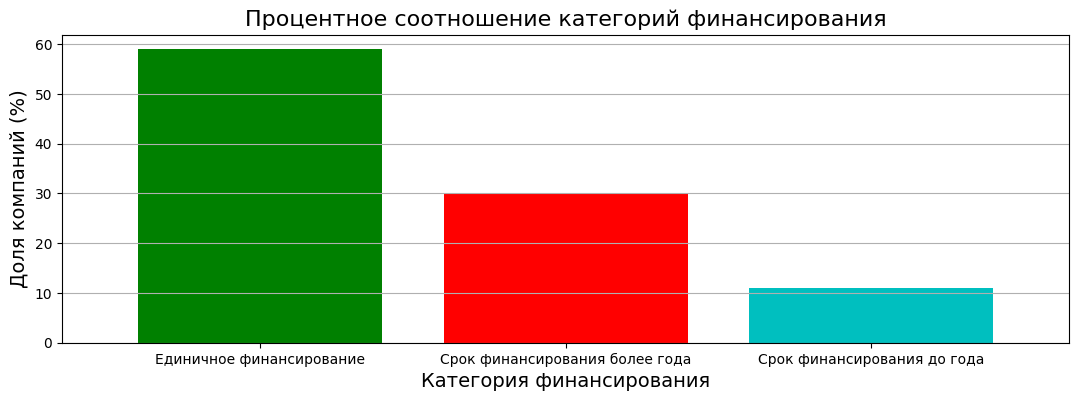

In [30]:
# Вычисляем процентное распределение
df_fund_cat = df_inv['funding_category'].value_counts(normalize=True) * 100

# Построим столбчатую диаграмму
ax = df_fund_cat.plot.bar(
    rot=0,
    figsize=(13, 4),
    color=colors(df_fund_cat), # Применяем функцию для создания палитры, описанную в начале
    width=0.8
)

# Настроим подписи и сетку
ax.set_title('Процентное соотношение категорий финансирования', fontsize=16)
ax.set_xlabel('Категория финансирования', fontsize=14)
ax.set_ylabel('Доля компаний (%)', fontsize=14)
plt.grid(axis='y')

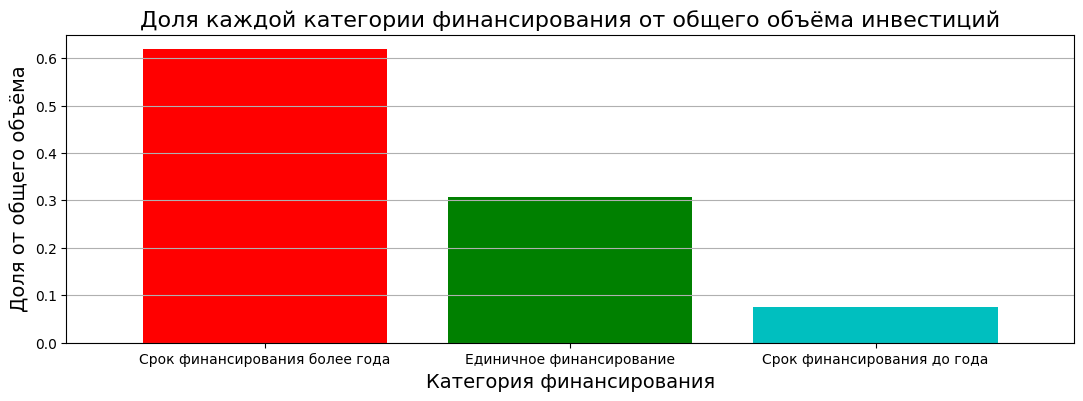

In [31]:
# Сгруппируем датафрейм по категории финансирования и посчитаем сумму инвестиций
category_sums = df_inv.groupby('funding_category')['funding_total_usd'].sum()

# Вычислим общюю сумму инвестиций
total_funding = category_sums.sum()

# Вычислим долю для каждой категории
category_shares = category_sums / total_funding

# Отсортируем датасет для графика
category_shares = category_shares.sort_values(ascending=False)

ax = category_shares.plot.bar(
    rot=0,
    figsize=(13, 4),
    color=colors(category_shares), # Функция с фиксированной палитрой
    width=0.8
)

# Настроим подписи и сетку
ax.set_title('Доля каждой категории финансирования от общего объёма инвестиций', fontsize=16)
ax.set_xlabel('Категория финансирования', fontsize=14)
ax.set_ylabel('Доля от общего объёма', fontsize=14)
plt.grid(axis='y')

Из гарафиков видно, что:
- Процент компаний, получивших `единичное финансирование`, чуть меньше 60-ти. Со `сроком финансирование более года` - ~30%. Со `сроком финансирования до года` -  чуть больше 10%.
- У компаний со `сроком финансирования более года` доля от общего объема инвестиций чуть больше 0,6. С `единичным финансированием` - чуть больше 0,3. Со `сроком финансирования до года` - меньше 0,1.

### 2.2 Выделение средних и нишевых сегментов рынка

Компании указывают свой сегмент рынка в столбце `market`. Рассчитаем, как часто в датасете встречается каждый из сегментов. Сегменты, к которым относится более 120 компаний, отнесем к массовым, сегменты, в которые входит от 35 до 120 включительно, отнесем к средним, а сегменты до 35 компаний отнесем к нишевым. Рассчитаем, сколько сегментов попадает в каждую из категорий.

Построим график распределения количества компаний в сегментах и отобразим на нём разделение на нишевые и средние сегменты.

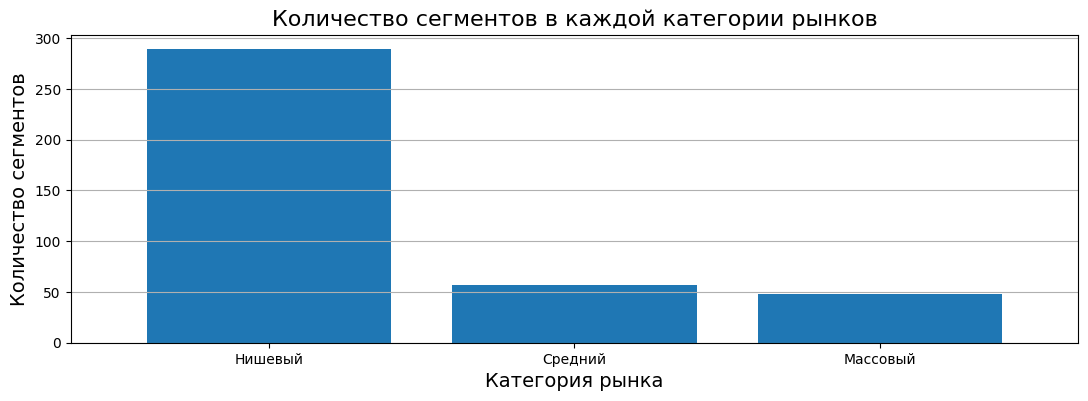

Количество массовых сегментов (> 120 компаний): 48
Количество средних сегментов (35–120 компаний): 57
Количество нишевых сегментов (< 35 компаний): 289


In [32]:
# Отфильтруем данные от индикатора пропуска и посчитаем нужные значения
market_counts = df_inv[df_inv['market'] != 'unknown']['market'].value_counts()

# Считаем количество сегментов рынка для каждой категории
mass_market = market_counts[market_counts > 120].count()
mid_market = market_counts[(market_counts >= 35) & (market_counts <= 120)].count()
niche_market = market_counts[market_counts < 35].count()

# Сделаем датафрейм для визуализации
categories = ['Массовый', 'Средний', 'Нишевый']
counts = [mass_market, mid_market, niche_market]
plot_df = pd.DataFrame({'Категория': categories, 'Количество сегментов': counts})\
    .set_index('Категория').sort_values(by='Количество сегментов',ascending=False)

# Строим визуализацию
ax = plot_df.plot.bar(
    legend=False,
    rot=0,
    figsize=(13, 4),
    width=0.8
)

# Настроим подписи и сетку
ax.set_title('Количество сегментов в каждой категории рынков', fontsize=16)
ax.set_xlabel('Категория рынка', fontsize=14)
ax.set_ylabel('Количество сегментов', fontsize=14)
plt.grid(axis='y')
plt.show()


# Выводим результаты
print(f"Количество массовых сегментов (> 120 компаний): {mass_market}")
print(f"Количество средних сегментов (35–120 компаний): {mid_market}")
print(f"Количество нишевых сегментов (< 35 компаний): {niche_market}")

- Из графика видно, что `нишевая` категория с количеством сегментов - 289 превалирует над остальными.
- В `средней` категории 57 сегментов рынка.
- На `массовом` рынке 48 сегментов.

Оставим в столбце `market` только массовые сегменты. Для остальных сегментов заменим значения на заглушки — `niche` для нишевых и `mid` для средних.

In [33]:
# Создадим индексы сегментов среднего и нишевого рынков
mid_market = market_counts[(market_counts >= 35) & (market_counts <= 120)].index
niche_market = market_counts[market_counts < 35].index

# Создадим копию столбца market для модификации
df_inv['market'] = df_inv['market'].copy()

# Замена значений: нишевые на 'niche', средние на 'mid', массовые остаются без изменений
df_inv.loc[df_inv['market'].isin(niche_market), 'market'] = 'niche'
df_inv.loc[df_inv['market'].isin(mid_market), 'market'] = 'mid'
# Проверим результат
df_inv['market'].value_counts()

software                4812
mid                     3839
biotechnology           3590
unknown                 2503
mobile                  2344
e-commerce              1866
curated web             1693
enterprise software     1381
health care             1185
clean technology        1180
games                   1117
advertising             1107
hardware + software     1062
social media            1003
health and wellness      873
education                844
niche                    830
finance                  828
analytics                667
manufacturing            596
security                 567
semiconductors           484
web hosting              424
consulting               349
hospitality              336
travel                   330
fashion                  303
news                     301
messaging                295
search                   291
real estate              279
saas                     272
music                    264
internet                 241
technology    

- Средний рынок встречается в датасете 3839 раз.
- Нишевый рынок встречается 830 раз.

## Шаг 3. Работа с выбросами и анализ

### 3.1. Анализируем и помечаем выбросы в каждом из сегментов

Заказчика интересует обычный для рассматриваемого периода размер средств, который предоставлялся компаниям.

По предобработанному столбцу `funding_total_usd` графическим образом оценим, какой размер общего финансирования для одной компании будет типичным, а какой — выбивающимся.

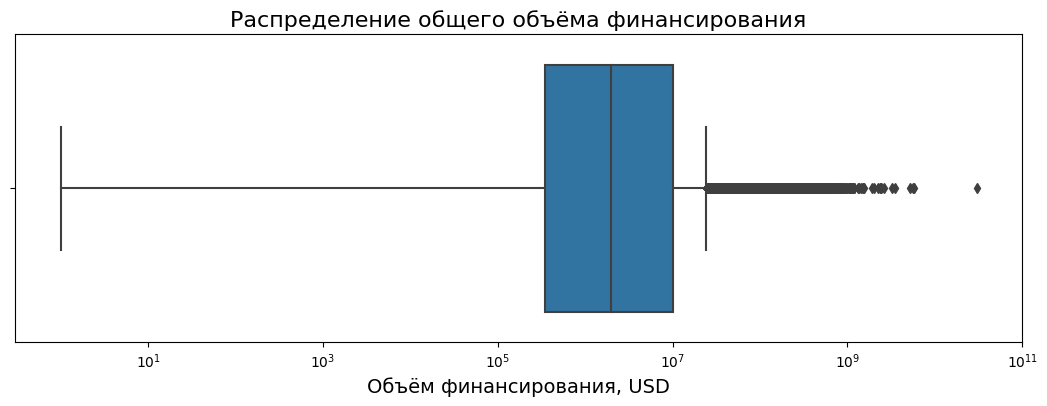


Типичные значения (межквартильный размах): от 350000.0 USD до 10000000.0 USD
Выбросы: значения > 24475000.0 USD


In [34]:
# Сделаем ящик с усами
plt.figure(figsize=(13, 4))
sns.boxplot(x=df_inv['funding_total_usd'])
plt.title('Распределение общего объёма финансирования', fontsize=16)
plt.xlabel('Объём финансирования, USD', fontsize=14)
plt.xscale('log')  # Логарифмическая шкала для лучшей читаемости

# Покажем график
plt.show()

# Расчитаем первый и третий квартили и IQR
Q1 = df_inv['funding_total_usd'].quantile(0.25)
Q3 = df_inv['funding_total_usd'].quantile(0.75)
IQR = Q3 - Q1

# Определим верхнюю границу для значений и выбросов
# Из графика видно, что снизу выбросов нет
upper_bound = Q3 + 1.5 * IQR

# Вывод результатов
print(f'''
Типичные значения (межквартильный размах): от {Q1} USD до {Q3} USD
Выбросы: значения > {upper_bound} USD''')

- Размер общего финансирования в нашем датасете имеет типичные значения от 350,000 USD до 10,000,000 USD.
- Значения выше 24,475,000 USD - выбросы.

Определим компании с аномальным объёмом общего финансирования.

Определим сегменты рынка с наибольшей долей компаний, получивших аномальное финансирование, и выведем топ таких сегментов.

In [35]:
# Оставим только выбросные значения финансирования и уберем неизвестные сегменты
# Посчитаем долю компаний в каждом сегменте и выведем топ-10
df_inv[(df_inv['funding_total_usd']>upper_bound)
      & (df_inv['market']!='unknown')]['market'].value_counts(normalize=True).round(4).head()*100

biotechnology       16.17
software             9.41
mid                  9.16
clean technology     6.37
health care          6.25
Name: market, dtype: float64

- Топ-5 сегментов по доле компаний с аномальным финансированием:
  1. `biotechnology` - доля 16,17%
  2. `software` - доля 9,41%
  4. `mid` - доля 9,16%
  5. `clean technology` - доля 6,37%
  6. `health care` - доля 6,25%

### 3.2 Определяем границы рассматриваемого периода, отбрасываем аномалии

Проверим по датасету, можно ли считать, что нам предоставили полные данные за 2014 год. Затем исключим из датасета компании, которые мы ранее посчитали получившими аномальное финансирование.

Далее на основе столбцов `mid_funding_at` и `funding_rounds` оставим в датасете данные только об определённых компаниях. Они должны были получать финансирование в годы, когда было зафиксировано 50 или более раундов финансирования.

In [36]:
print(f'''
Количество компаний, которые получили первое финансирование в 2014 году:\n{df_inv[df_inv['first_funding_at'].dt.year==2014]['name'].nunique()}
Для сравнения - в 2013 году:\n{df_inv[df_inv['first_funding_at'].dt.year==2013]['name'].nunique()}\n
Количество компаний, которые получили последнее финансировние в 2014 году:\n{df_inv[df_inv['last_funding_at'].dt.year==2014]['name'].nunique()}
И для сравнения - в 2013 году:\n{df_inv[df_inv['last_funding_at'].dt.year==2013]['name'].nunique()}\n
Максимальный месяц в first_funding_at в 2014: {df_inv[df_inv['first_funding_at'].dt.year==2014]['first_funding_at'].dt.month.max()}
Максимальный месяц в last_funding_at в 2014: {df_inv[df_inv['last_funding_at'].dt.year==2014]['last_funding_at'].dt.month.max()}
''')


Количество компаний, которые получили первое финансирование в 2014 году:
6465
Для сравнения - в 2013 году:
7172

Количество компаний, которые получили последнее финансировние в 2014 году:
11885
И для сравнения - в 2013 году:
8678

Максимальный месяц в first_funding_at в 2014: 12
Максимальный месяц в last_funding_at в 2014: 12



- Судя по результатам проверки можно сказать, что данные за 2014 год полные. Теперь исключим из датасета компании с аномальным финансированием.

In [37]:
df_inv = df_inv[df_inv['funding_total_usd']<=upper_bound]

- Теперь можно отфильтровать датасет.

In [38]:
# Выделим в новый столбец год из 'mid_funding_year'
df_inv['mid_funding_year'] = df_inv['mid_funding_at'].dt.year

# Сделаем датафрейм с группировкой по годам и суммой раундов финансирования
df_years = df_inv.groupby('mid_funding_year')['funding_rounds'].sum().reset_index()

# Создадим список лет, когда раундов финансирования было больше 50 и отфильтруем по нему основной датасет
years_list = df_years[df_years['funding_rounds']>=50]['mid_funding_year'].tolist()
df_inv = df_inv[df_inv['mid_funding_year'].isin(years_list)]

### 3.3. Анализ типов финансирования по объёму и популярности

Построим график, который покажет, какие типы финансирования в сумме привлекли больше всего денег. Ориентируемся на значения в столбцах `seed`, `venture`, `equity_crowdfunding`, `undisclosed`, `convertible_note`, `debt_financing`, `angel`, `grant`, `private_equity`, `post_ipo_equity`, `post_ipo_debt`, `secondary_market` и `product_crowdfunding`.

Также построим график, который покажет популярность разных типов финансирования — какие типы финансирования чаще всего используются компаниями, то есть встречаются в датасете наибольшее количество раз.

Сравним графики и выделим часто используемые типы финансирования, которые при этом характеризуются небольшими объёмами, и наоборот — те, что встречаются редко, но при этом характеризуются значительным объёмом предоставленных сумм.

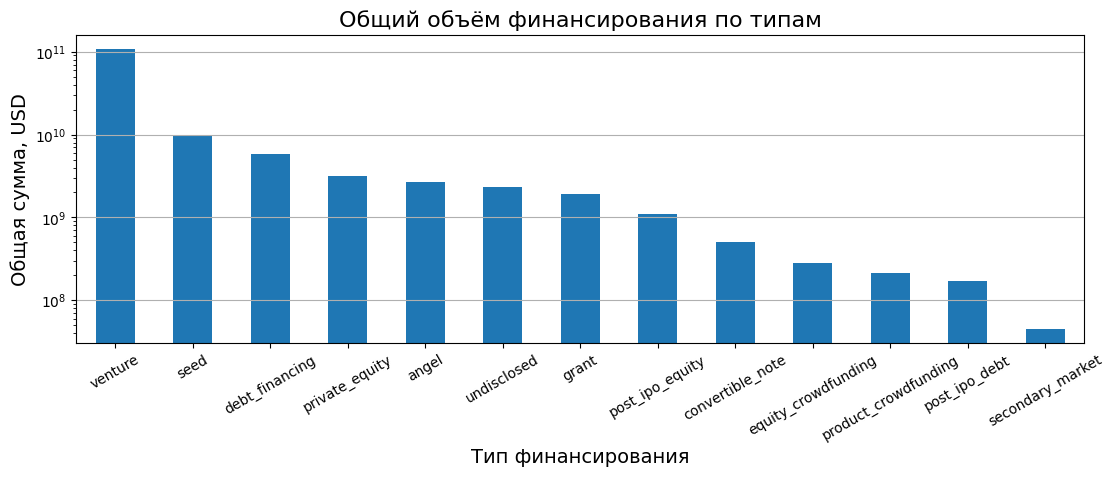

In [39]:
funding_columns = [
    'seed', 'venture', 'equity_crowdfunding', 'undisclosed', 'convertible_note',
    'debt_financing', 'angel', 'grant', 'private_equity', 'post_ipo_equity',
    'post_ipo_debt', 'secondary_market', 'product_crowdfunding'
]

# Подсчёт суммы для каждого типа финансирования
funding_sums = df_inv[funding_columns].sum()

# Сортировка по убыванию суммы
funding_sums = funding_sums.sort_values(ascending=False)

# Строим график
ax = funding_sums.plot.bar(
    legend=False,
    rot=30,
    figsize=(13, 4)
)

# Настроим подписи и сетку
ax.set_title('Общий объём финансирования по типам', fontsize=16)
ax.set_xlabel('Тип финансирования', fontsize=14)
ax.set_ylabel('Общая сумма, USD', fontsize=14)
plt.yscale('log')
plt.grid(axis='y')

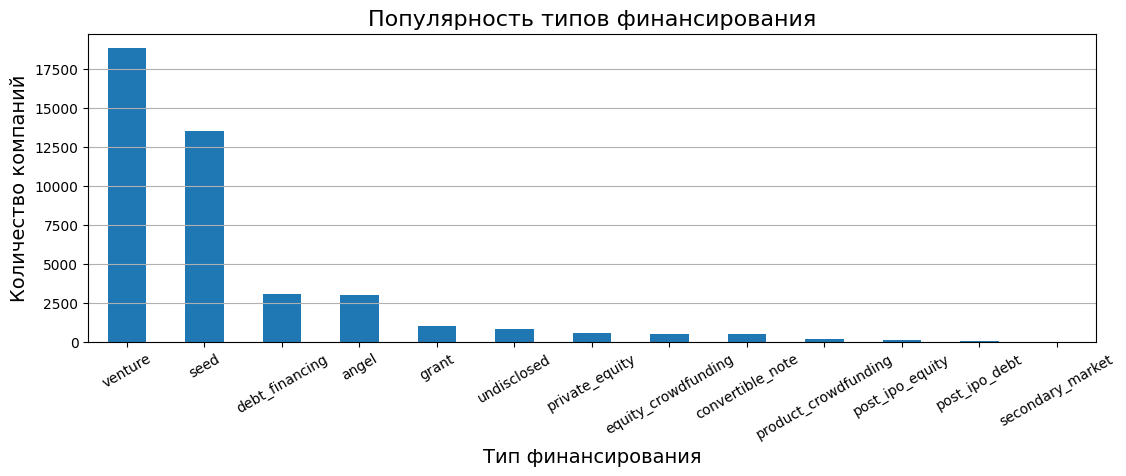

In [40]:
# Метод gt проверит значения столбцов >0 и вернет булевы значения, потом их можно просто сложить
funding_counts = df_inv[funding_columns].gt(0).sum()

# Сортировка по убыванию количества
funding_counts = funding_counts.sort_values(ascending=False)

# Строим график
ax = funding_counts.plot.bar(
    legend=False,
    rot=30,
    figsize=(13, 4)
)

# Настроим подписи и сетку
ax.set_title('Популярность типов финансирования', fontsize=16)
ax.set_xlabel('Тип финансирования', fontsize=14)
ax.set_ylabel('Количество компаний', fontsize=14)
plt.grid(axis='y')

- Типы финансирования `private_equity` и `post_ipo_equity` выделаются меньшей популярностью, но большей суммой потраченных финансов.
- Типы финансирования `grant` и `equity_crowdfunding`, наоборот, выделаются большей популярность, но меньшими вложениями. 

Построим график суммарных объёмов возвратов от разных типов финансирования за весь период на основе дополнительного датасета.

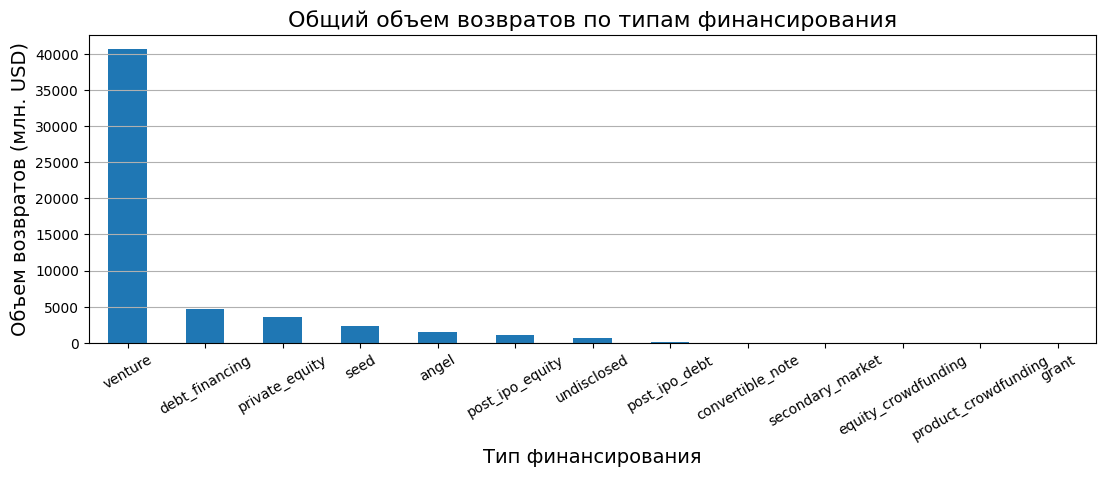

In [41]:
df_re_sum = df_re.sum().sort_values(ascending=False)

# Строим график
ax = df_re_sum.plot.bar(
    legend=False,
    rot=30,
    figsize=(13, 4)
)

# Настроим подписи и сетку
ax.set_title('Общий объем возвратов по типам финансирования', fontsize=16)
ax.set_xlabel('Тип финансирования', fontsize=14)
ax.set_ylabel('Объем возвратов (млн. USD)', fontsize=14)
plt.grid(axis='y')

- Больше всего возвратов по венчурным инвестициям

## Шаг 4. Анализ динамики

### 4.1 Динамика предоставления финансирования по годам

Используя столбцы `funding_total_usd` и `funding_rounds`, рассчитаем для каждой компании средний объём одного раунда финансирования.

На основе получившейся таблицы построим графики, отражающие:
* динамику типичного размера средств, которые стартапы получали в рамках одного раунда финансирования;

* динамику общего количества раундов за каждый год, то есть насколько активно происходили инвестиции на рынке (чем больше раундов, тем выше активность).

На основе полученных данных ответим на вопросы:
* В каком году типичный размер средств, собранных в рамках одного раунда, был максимальным?

* Какая тенденция наблюдалась в 2014 году по количеству раундов и средств, выделяемых в рамках каждого раунда?

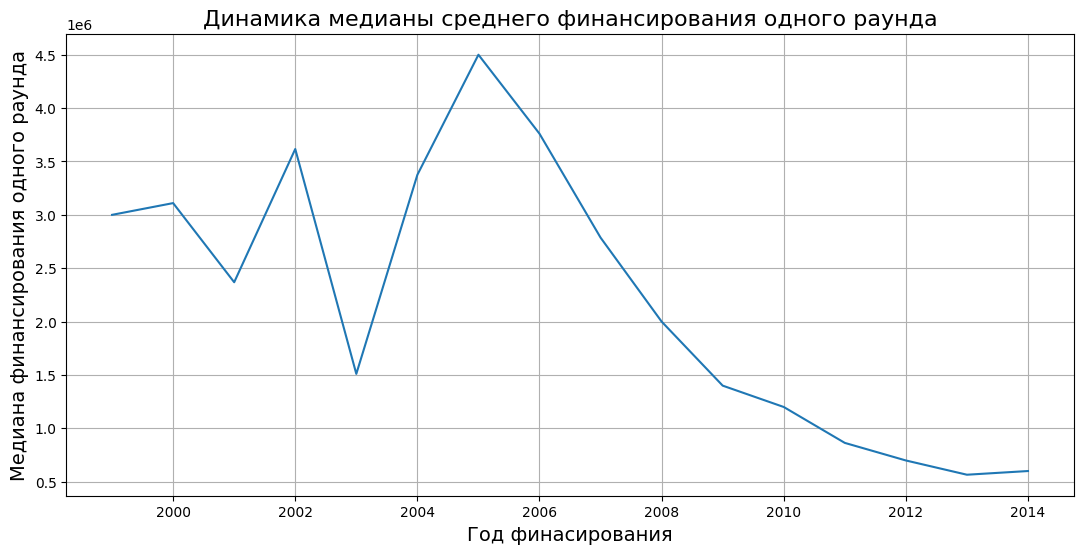

In [42]:
# Сделаем новый столбец со средним финансированием за один раунд
df_inv['avg_fund_per_round'] = df_inv['funding_total_usd'] / df_inv['funding_rounds']

# Создадим таблицу с медианой avg_fund_per_round за год
median_fund_per_round_year = df_inv.groupby('mid_funding_year')['avg_fund_per_round'].median()

# Делаем линейный график
plt.figure(figsize=(13,6))
median_fund_per_round_year.plot.line()
plt.title('Динамика медианы среднего финансирования одного раунда', fontsize=16)
plt.xlabel('Год финасирования', fontsize=14)
plt.ylabel('Медиана финансирования одного раунда', fontsize=14)
plt.grid(axis='both')

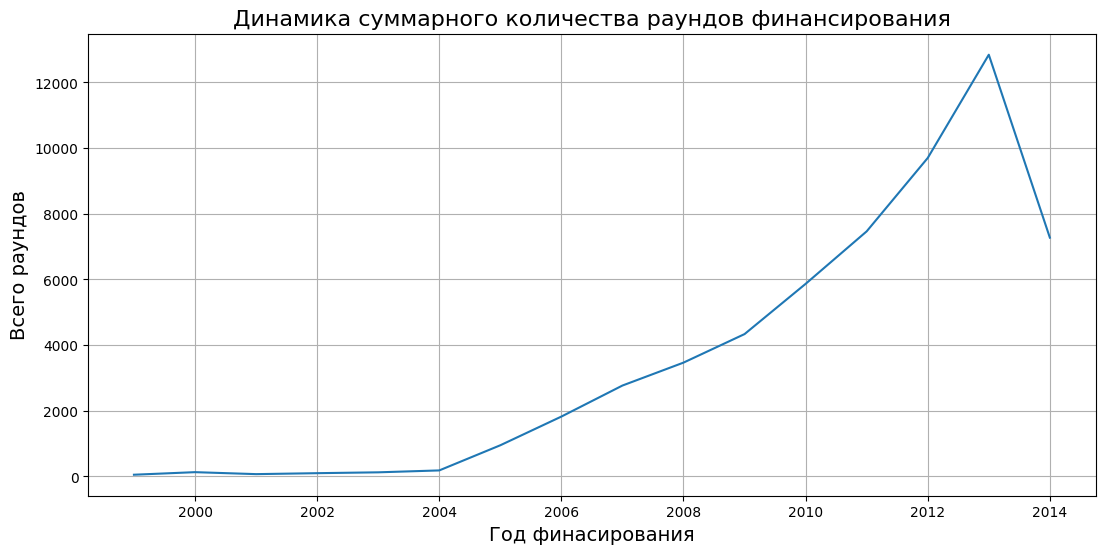

In [43]:
# Группируем данные по годам и считаем сумму раундов финансирования
rounds_per_year = df_inv.groupby('mid_funding_year')['funding_rounds'].sum()

# Строим линейный график
plt.figure(figsize=(13,6))
rounds_per_year.plot.line()
plt.title('Динамика суммарного количества раундов финансирования', fontsize=16)
plt.xlabel('Год финасирования', fontsize=14)
plt.ylabel('Всего раундов', fontsize=14)
plt.grid(axis='both')

- Максимальный типичный размер средств, собранный в рамках одного раунда, наблюдался в 2005 году.
- В 2014 году количество раундов финансирования резко упало, а типичный размер средств, собранный в рамках одного раунда, немного вырос.

### 4.2 Динамика размера общего финансирования по массовым сегментам рынка для растущих в 2014 году сегментов

Составим сводную таблицу, в которой указывается суммарный размер общего финансирования `funding_total_usd` по годам и сегментам рынка. Отберем из неё только те сегменты, которые показывали рост размера суммарного финансирования в 2014 году по сравнению с 2013.

На графике отразим, как менялся суммарный размер общего финансирования в каждом из отобранных сегментов по годам, за которые у вас достаточно данных. Рассматрим только массовые сегменты, а средние и нишевые исключите.

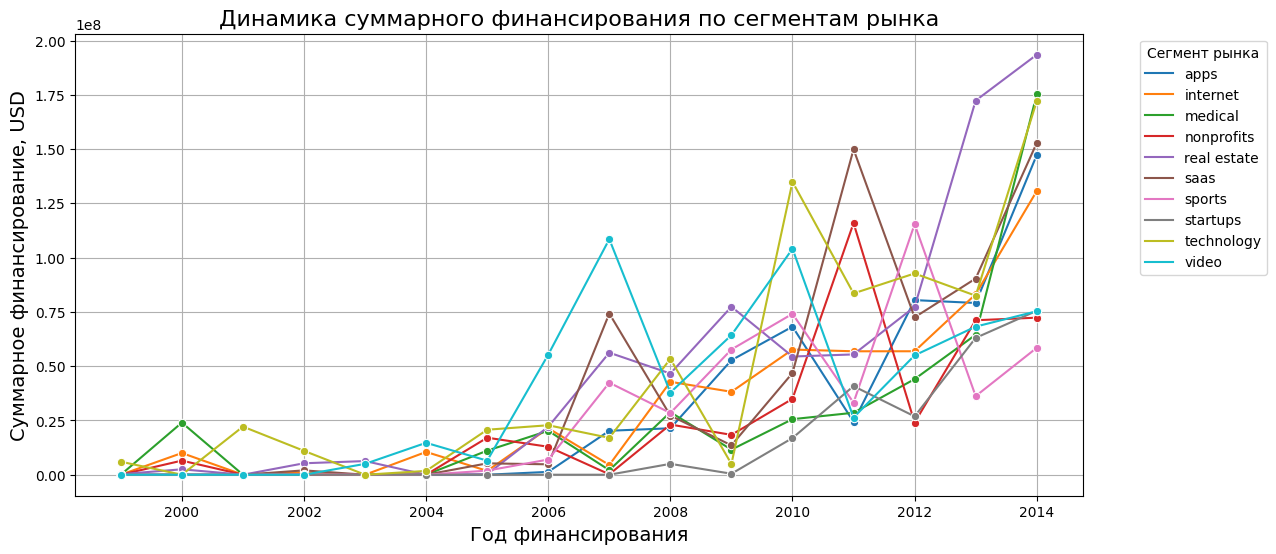

In [44]:
# Сводная таблица с суммой инвестиций по годам для каждого сегмента
pivot_funding = pd.pivot_table(df_inv,
                              index='market',
                              columns='mid_funding_year',
                              values='funding_total_usd',
                              aggfunc='sum',
                              fill_value=0)
# Фильтруем таблицу по заданию, убираем заглушки для пропусков, убираем нишевый и средний рынок
pivot_filtered = pivot_funding[(pivot_funding[2014]>pivot_funding[2013]) & (pivot_funding.index!='unknown')
                              & (pivot_funding.index!='niche') & (pivot_funding.index!='mid')]

# Для графика переделаем таблицу в "длинный формат" с помощью метода melt
pivot_melted = pivot_filtered.reset_index().melt(
    id_vars='market',  # Столбец, который оставляем без изменений
    value_vars=pivot_filtered.columns, # Значения для столбца с годами
    var_name='mid_funding_year',   # Названия для столбцов
    value_name='funding_total_usd'
)

# Создадим линейный график
plt.figure(figsize=(13, 6))
sns.lineplot(
    data=pivot_melted,
    x='mid_funding_year',
    y='funding_total_usd',
    hue='market',
    marker='o'
)
plt.title('Динамика суммарного финансирования по сегментам рынка', fontsize=16)
plt.xlabel('Год финансирования', fontsize=14)
plt.ylabel('Суммарное финансирование, USD', fontsize=14)
plt.grid(axis='both')
plt.legend(title='Сегмент рынка', bbox_to_anchor=(1.05, 1), loc='upper left')

На этом графике плохо видно конечно, многовато сегментов получилсоь. Может я что-то не так отфильтровал.

Самый быстрый и уверенный рост показывают сегменты: `real estate`, `medical`, `technology`, `saas`, `apps` и `internet`. Хотя сегменты `saas` и `technology` до серьезного рывка в 2014 довольно сильно проседали в 2012.

### 4.3 Годовая динамика доли возвращённых средств по типам финансирования

Заказчик хочет знать, какая часть вложенных или выданных денег со временем возвращается обратно инвесторам или финансистам. Для каждого года и каждого вида финансирования нужно рассчитать нормированные значения возврата средств: то есть какую долю возвращённые средства составляют от предоставленных. При этом слишком большие аномальные значения, то есть неадекватные выбросы, нужно заменить на пропуски.

In [45]:
# Поскольку в датасете с возвратами все значения в миллионах нужно сделать значения сопоставимыми
df_inv[funding_columns] = df_inv[funding_columns]/1e+6

In [46]:
# В датасете с возвратами нет 1999го года
# Группируем данные по году и суммируем столбцы с данными о финансировании
df_fund = df_inv[df_inv['mid_funding_year']!=1999].groupby('mid_funding_year')[funding_columns].sum()

# Делим датафрейм с возвратами на датафрейм с вложениями и дабавляем небольшое число, чтобы избежать деления на 0
df_share = df_re/(df_fund+1e-60)
df_share

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,0.996471,0.190532,0.000000e+00,0.437777,0.000000e+00,1.237143,0.246489,0.0,0.000000e+00,2.710694e-01,0.000000,2.591054e-02,0.000000
2001,0.702616,0.108440,0.000000e+00,0.327026,1.000000e+58,0.544242,1.180000,0.0,0.000000e+00,4.600000e+59,0.000000,4.600000e+59,0.000000
2002,0.696235,0.699096,0.000000e+00,0.608878,2.000000e+58,0.238999,1.136667,0.0,9.183866e-02,1.133333e+00,0.000000,6.000000e+58,0.000000
2003,0.707930,0.684200,0.000000e+00,0.914397,1.000000e+58,1.038095,0.367780,0.0,1.620000e+60,2.110000e+60,0.000000,8.000000e+58,0.000000
2004,0.580541,0.785408,0.000000e+00,0.710814,1.000000e+58,0.644728,0.833504,0.0,2.190000e+60,3.380000e+60,0.000000,5.500000e+59,0.000000
2005,0.649966,0.593756,0.000000e+00,0.346294,2.000000e+58,0.550783,0.493685,0.0,4.800000e-01,7.318565e-01,0.000000,5.000000e+58,0.000000
2006,0.864151,0.392926,2.036317e-01,1.104582,1.507471e-01,0.979646,0.656122,0.0,5.544585e-01,2.058000e+61,0.000000,1.200000e+59,0.000000
2007,0.348141,0.379353,1.000000e+58,0.536623,2.891836e-01,0.674262,0.740528,0.0,1.217571e+00,2.030000e+00,0.000000,5.700000e+59,0.000000
2008,0.288370,0.260944,3.000000e+58,0.351021,1.113581e-01,1.450161,0.401288,0.0,2.801080e+00,8.428000e+61,0.000000,4.700000e+59,0.000000


Если считать нормированные значения по каждому столбцу, то аномальные значения, которые получились из-за деления на 1е-60, влезают и в медиану, и в процентили. Тогда я посчитал нормированные значения для всего датасета вот так:

`data = df_share.to_numpy().flatten()`

`data_Q1 = np.percentile(data, 25)`

`data_Q3 = np.percentile(data, 75)`

`data_IQR = data_Q3 - data_Q1`

`upper = data_Q3 + 1.5 * data_IQR`


Получилось значение меньше 3, но в датасете есть значения больше 3 (в столбце `post_ipo_equity`), которые я не счел бы аномальными.

В итоге я решил просто отфильтровать датасет по значениям меньше 10, потому что считаю их все адекватными. Да и большой разницы для дальнейших заданий не было бы, отфильтруй я `df_share < 10` или `df_share < upper`. Возможно даже, что вообще разницы бы не было)

In [47]:
# Отфильтруем значения, которые получились в результате деления на 1е-60
df_share = df_share[df_share<10]
df_share

,seed,venture,equity_crowdfunding,undisclosed,convertible_note,debt_financing,angel,grant,private_equity,post_ipo_equity,post_ipo_debt,secondary_market,product_crowdfunding
year,,,,,,,,,,,,,
2000,0.996471,0.190532,0.000000,0.437777,0.000000,1.237143,0.246489,0.0,0.000000,0.271069,0.000000,0.025911,0.000000
2001,0.702616,0.108440,0.000000,0.327026,NaN,0.544242,1.180000,0.0,0.000000,NaN,0.000000,NaN,0.000000
2002,0.696235,0.699096,0.000000,0.608878,NaN,0.238999,1.136667,0.0,0.091839,1.133333,0.000000,NaN,0.000000
2003,0.707930,0.684200,0.000000,0.914397,NaN,1.038095,0.367780,0.0,NaN,NaN,0.000000,NaN,0.000000
2004,0.580541,0.785408,0.000000,0.710814,NaN,0.644728,0.833504,0.0,NaN,NaN,0.000000,NaN,0.000000
2005,0.649966,0.593756,0.000000,0.346294,NaN,0.550783,0.493685,0.0,0.480000,0.731857,0.000000,NaN,0.000000
2006,0.864151,0.392926,0.203632,1.104582,0.150747,0.979646,0.656122,0.0,0.554459,NaN,0.000000,NaN,0.000000
2007,0.348141,0.379353,NaN,0.536623,0.289184,0.674262,0.740528,0.0,1.217571,2.030000,0.000000,NaN,0.000000
2008,0.288370,0.260944,NaN,0.351021,0.111358,1.450161,0.401288,0.0,2.801080,NaN,0.000000,NaN,0.000000


Построим график, на котором отобразите нормированные значения возврата средств для типов финансирования `venture`, `debt_financing`, `private_equity`, `seed` и `angel`.

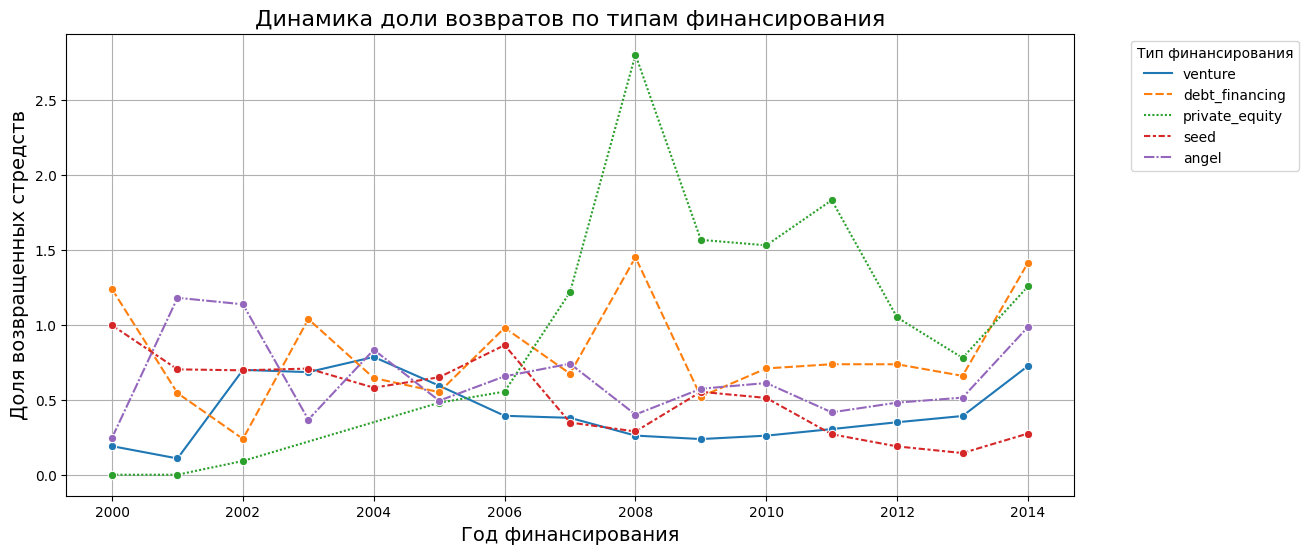

In [48]:
funding_types = ['venture', 'debt_financing', 'private_equity', 'seed', 'angel']

# Создадим линейный график
plt.figure(figsize=(13, 6))
sns.lineplot(
    data=df_share[funding_types],
    marker='o'
)
plt.title('Динамика доли возвратов по типам финансирования', fontsize=16)
plt.xlabel('Год финансирования', fontsize=14)
plt.ylabel('Доля возвращенных стредств', fontsize=14)
plt.grid(axis='both')
plt.legend(title='Тип финансирования', bbox_to_anchor=(1.05, 1), loc='upper left')

- Если сравнивать с 2013м, то все типпы финансирования показывают рост показателя доли возвратов.
- Если смотреть на большую картину, то устойчивый, хоть и небольшой, рост в пределах пяти лет показывает только `venture`.
- К неплохо растущим я бы еще добавил `angel` и `debt_financing`, хотя у последнего колебания довольно сильные.
- Тип `private_equity` с 2007 по 2012 имел сильные колебания, но не опускался ниже единицы. В 2013 просел ниже 1, но в следующем году опять пошел вверх.
- С другой стороны за значение `1` в 2014 году, т.е. возврат привысил траты, перевалили только `debt_financing` и `private_equity`. Но, понятное дело, это в среднем "по больнице".


## Шаг 5. Итоговый вывод и рекомендации

Опираясь на результаты анализа, дадим рекомендацию заказчику:

* в какую отрасль стоит инвестировать;
* какой тип финансирования при этом будет наиболее уместным.

Подведем итоги проекта:
* опишем, какие шаги были выполнены;
* какие выводы удалось сделать;
* насколько выводы согласуются между собой или, наоборот, вызывают сомнения.

**Общие рекомендации:**
- На основании анализа можно назвать привлекательными для инвестиций следующие сегменты: `real estate`, `medical`, `technology`, `saas`, `apps` и `internet`. Они все, кроме `saas` и `technology`, демонстрируют стабильный рост вложенных инвестиций. Отрасли `saas` и `technology` проседали в районе 2012го.
- Наиболее стабильный рост возвратов по инвестициям за последние 5 лет показывает тип `venture`. Так же стоит отметить типы `angel` и `debt_financing`, - они показывают рост 2014 и относительно стабильны. И единственный тип финансирования, который на протяжении шести лет имел показатель доли возрата больше 1 - `private_equity`. В 2013 он просел ниже, но в 2014 опять пошел в рост.

**Общие итоги проекта:**
- Была проведена загрузка и предобработка данных:
    - Исправлены типы данных в столбцах
    - Добавлены недостающие значения
    - Обработаны пропуски и дубликаты
- Добавлен новый признак по срокам финансирования - `единичное`, `до года` и `более года`
- Выделены массовый, средний и нишевый рынки. Для средних и нишевых дабавлены заглушки. По отдельности рассматривали только массовый рынок.
- Определены выбросы в столбце `funding_total_usd`. На основе этой информации были определены сегменты рынка с наибольшей долей компаний, получивших аномальное финансирование. Выбросы в столбце `funding_total_usd` были отброшены.
- В датасете оставлены только компании, которые получали финансирование в годы, когда общее количество раундов превышало 50.
- Были выделены методы финансирования, которые привлекают больше всего денег и методы, которые пользуются большей популярностью.
- Был проведен анализ динамики раундов финансирования - их количество за годы и типичный объем инвестиций за один раунд за годы.
- Изучена динамика объемов финансирования по сегментам рынка, которые показали рост в 2014 в сравнении с 2013.
- Так же изучена годовая динамика доли возвращенных средств для типов финансирования: `venture`, `debt_financing`, `private_equity`, `seed` и `angel`.

**Выводы:**
- С годами падает типичное финансирование одного раунда, но растет их количество. Хотя в 2014 тренд немного поломался.
- Самый быстрый и уверенный рост показывают сегменты: `real estate`, `medical`, `apps` и `internet`. Сегменты `saas` и `technology` до серьезного рывка в 2014 довольно сильно проседали в 2012.
- Самые популярные типы финансирования это `seed` и `venture`, хотя они не показывают большой доли возвратов.